# DeepSKAN Ablation Study Comparison

This notebook compares the full **DeepSKAN** model against three ablation variants on **MSL** and **SWaT**.

## Model variants

- **DeepSKAN**: Wavelet KAN + DeepSVDD + Attention
- **DeepSKAN W/O Attention**: Wavelet KAN + DeepSVDD
- **DeepSKAN W/O KAN**: Attention + DeepSVDD
- **DeepSKAN W/O DeepSVDD**: Attention + Wavelet KAN

## Main evaluation metrics

The main metrics used for comparison are:

- **Best F1 PA**
- **Precision PA**
- **Recall PA**
- **AUPRC PA**

A higher value is better for all metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

records = [
    {
        "Dataset": "MSL",
        "Variant": "DeepSKAN",
        "Best F1 PA": 0.9241755144226247,
        "Precision PA": 0.915828677839851,
        "Recall PA": 0.932675896074341,
        "AUPRC PA": 0.9047260530551217
    },
    {
        "Dataset": "SWaT",
        "Variant": "DeepSKAN",
        "Best F1 PA": 0.950757197869071,
        "Precision PA": 0.9351584731625945,
        "Recall PA": 0.9668851328044153,
        "AUPRC PA": 0.9809713933603839
    },
    {
        "Dataset": "MSL",
        "Variant": "DeepSKAN W/O Attention",
        "Best F1 PA": 0.7245647969052218,
        "Precision PA": 0.7392934675350306,
        "Recall PA": 0.7104115304380808,
        "AUPRC PA": 0.6606484211506457
    },
    {
        "Dataset": "SWaT",
        "Variant": "DeepSKAN W/O Attention",
        "Best F1 PA": 0.9062763697733286,
        "Precision PA": 0.8680924597718236,
        "Recall PA": 0.9479739463912505,
        "AUPRC PA": 0.9703678489616743
    },
    {
        "Dataset": "MSL",
        "Variant": "DeepSKAN W/O KAN",
        "Best F1 PA": 0.8260663056901296,
        "Precision PA": 0.8275599543205177,
        "Recall PA": 0.8245780390669448,
        "AUPRC PA": 0.8956023984096434
    },
    {
        "Dataset": "SWaT",
        "Variant": "DeepSKAN W/O KAN",
        "Best F1 PA": 0.8979670323800565,
        "Precision PA": 0.9481996209728364,
        "Recall PA": 0.8527889941764909,
        "AUPRC PA": 0.9323704180799881
    },
    {
        "Dataset": "MSL",
        "Variant": "DeepSKAN W/O DeepSVDD",
        "Best F1 PA": 0.9242623566998679,
        "Precision PA": 0.9159992549823058,
        "Recall PA": 0.932675896074341,
        "AUPRC PA": 0.9357563135066677
    },
    {
        "Dataset": "SWaT",
        "Variant": "DeepSKAN W/O DeepSVDD",
        "Best F1 PA": 0.8918091918618783,
        "Precision PA": 0.8906360674316476,
        "Recall PA": 0.8929854107907392,
        "AUPRC PA": 0.8749565855104269
    }
]

df = pd.DataFrame(records)

main_metrics = ["Best F1 PA", "Precision PA", "Recall PA", "AUPRC PA"]

df["Average Main Score"] = df[main_metrics].mean(axis=1)

df

,Dataset,Variant,Best F1 PA,Precision PA,Recall PA,AUPRC PA,Average Main Score
0,MSL,DeepSKAN,0.924176,0.915829,0.932676,0.904726,0.919352
1,SWaT,DeepSKAN,0.950757,0.935158,0.966885,0.980971,0.958443
2,MSL,DeepSKAN W/O Attention,0.724565,0.739293,0.710412,0.660648,0.708730
3,SWaT,DeepSKAN W/O Attention,0.906276,0.868092,0.947974,0.970368,0.923178
4,MSL,DeepSKAN W/O KAN,0.826066,0.827560,0.824578,0.895602,0.843452
5,SWaT,DeepSKAN W/O KAN,0.897967,0.948200,0.852789,0.932370,0.907832
6,MSL,DeepSKAN W/O DeepSVDD,0.924262,0.915999,0.932676,0.935756,0.927173
7,SWaT,DeepSKAN W/O DeepSVDD,0.891809,0.890636,0.892985,0.874957,0.887597


## Rounded comparison table

This table gives a clean view of the main results.

In [2]:
display_cols = ["Dataset", "Variant"] + main_metrics + ["Average Main Score"]
rounded_df = df[display_cols].copy()
for col in main_metrics + ["Average Main Score"]:
    rounded_df[col] = rounded_df[col].round(4)

rounded_df.sort_values(["Dataset", "Average Main Score"], ascending=[True, False])

,Dataset,Variant,Best F1 PA,Precision PA,Recall PA,AUPRC PA,Average Main Score
6,MSL,DeepSKAN W/O DeepSVDD,0.9243,0.9160,0.9327,0.9358,0.9272
0,MSL,DeepSKAN,0.9242,0.9158,0.9327,0.9047,0.9194
4,MSL,DeepSKAN W/O KAN,0.8261,0.8276,0.8246,0.8956,0.8435
2,MSL,DeepSKAN W/O Attention,0.7246,0.7393,0.7104,0.6606,0.7087
1,SWaT,DeepSKAN,0.9508,0.9352,0.9669,0.9810,0.9584
3,SWaT,DeepSKAN W/O Attention,0.9063,0.8681,0.9480,0.9704,0.9232
5,SWaT,DeepSKAN W/O KAN,0.8980,0.9482,0.8528,0.9324,0.9078
7,SWaT,DeepSKAN W/O DeepSVDD,0.8918,0.8906,0.8930,0.8750,0.8876


## Best variant per dataset

The following table ranks the variants inside each dataset using the average of the four main metrics.

In [3]:
ranking_per_dataset = (
    df.sort_values(["Dataset", "Average Main Score"], ascending=[True, False])
      .groupby("Dataset")
      .head(4)
      .reset_index(drop=True)
)

ranking_per_dataset[display_cols].round(4)

,Dataset,Variant,Best F1 PA,Precision PA,Recall PA,AUPRC PA,Average Main Score
0,MSL,DeepSKAN W/O DeepSVDD,0.9243,0.9160,0.9327,0.9358,0.9272
1,MSL,DeepSKAN,0.9242,0.9158,0.9327,0.9047,0.9194
2,MSL,DeepSKAN W/O KAN,0.8261,0.8276,0.8246,0.8956,0.8435
3,MSL,DeepSKAN W/O Attention,0.7246,0.7393,0.7104,0.6606,0.7087
4,SWaT,DeepSKAN,0.9508,0.9352,0.9669,0.9810,0.9584
5,SWaT,DeepSKAN W/O Attention,0.9063,0.8681,0.9480,0.9704,0.9232
6,SWaT,DeepSKAN W/O KAN,0.8980,0.9482,0.8528,0.9324,0.9078
7,SWaT,DeepSKAN W/O DeepSVDD,0.8918,0.8906,0.8930,0.8750,0.8876


## Winner per dataset

The winner is selected using the highest **Average Main Score** across the four main metrics.

In [4]:
winner_per_dataset = (
    df.loc[df.groupby("Dataset")["Average Main Score"].idxmax(), display_cols]
      .sort_values("Dataset")
      .reset_index(drop=True)
)

winner_per_dataset.round(4)

,Dataset,Variant,Best F1 PA,Precision PA,Recall PA,AUPRC PA,Average Main Score
0,MSL,DeepSKAN W/O DeepSVDD,0.9243,0.9160,0.9327,0.9358,0.9272
1,SWaT,DeepSKAN,0.9508,0.9352,0.9669,0.9810,0.9584


## Overall ranking across both datasets

This table averages each variant across **MSL** and **SWaT**.

In [5]:
overall = (
    df.groupby("Variant")[main_metrics + ["Average Main Score"]]
      .mean()
      .sort_values("Average Main Score", ascending=False)
      .reset_index()
)

overall.round(4)

,Variant,Best F1 PA,Precision PA,Recall PA,AUPRC PA,Average Main Score
0,DeepSKAN,0.9375,0.9255,0.9498,0.9428,0.9389
1,DeepSKAN W/O DeepSVDD,0.9080,0.9033,0.9128,0.9054,0.9074
2,DeepSKAN W/O KAN,0.8620,0.8879,0.8387,0.9140,0.8756
3,DeepSKAN W/O Attention,0.8154,0.8037,0.8292,0.8155,0.8160


## Contribution analysis against the full DeepSKAN model

For an ablation study, the most important comparison is the performance drop from the full model to each ablated variant.

A positive value means the full model is better than the ablation.  
A negative value means the ablation is better than the full model.

In [6]:
full = df[df["Variant"] == "DeepSKAN"].set_index("Dataset")

ablation_rows = []
for _, row in df[df["Variant"] != "DeepSKAN"].iterrows():
    dataset = row["Dataset"]
    variant = row["Variant"]
    full_row = full.loc[dataset]

    result = {
        "Dataset": dataset,
        "Ablation": variant,
    }
    for metric in main_metrics + ["Average Main Score"]:
        result[f"Full - Ablation {metric}"] = full_row[metric] - row[metric]
    ablation_rows.append(result)

drop_df = pd.DataFrame(ablation_rows)
drop_df.round(4)

,Dataset,Ablation,Full - Ablation Best F1 PA,Full - Ablation Precision PA,Full - Ablation Recall PA,Full - Ablation AUPRC PA,Full - Ablation Average Main Score
0,MSL,DeepSKAN W/O Attention,0.1996,0.1765,0.2223,0.2441,0.2106
1,SWaT,DeepSKAN W/O Attention,0.0445,0.0671,0.0189,0.0106,0.0353
2,MSL,DeepSKAN W/O KAN,0.0981,0.0883,0.1081,0.0091,0.0759
3,SWaT,DeepSKAN W/O KAN,0.0528,-0.0130,0.1141,0.0486,0.0506
4,MSL,DeepSKAN W/O DeepSVDD,-0.0001,-0.0002,0.0000,-0.0310,-0.0078
5,SWaT,DeepSKAN W/O DeepSVDD,0.0589,0.0445,0.0739,0.1060,0.0708


## Visualization: Average main score by dataset

This plot compares variants using the average of the four main metrics.

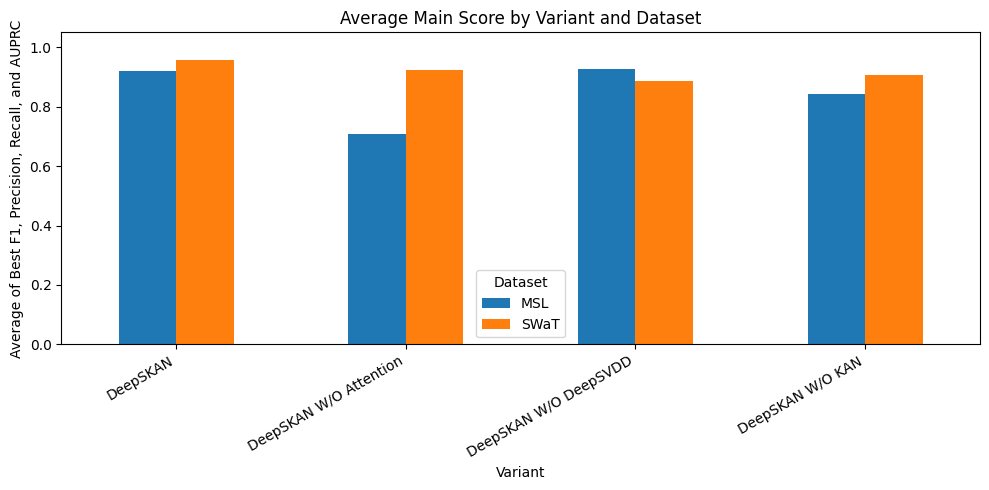

In [7]:
pivot_avg = df.pivot(index="Variant", columns="Dataset", values="Average Main Score")

ax = pivot_avg.plot(kind="bar", figsize=(10, 5))
plt.title("Average Main Score by Variant and Dataset")
plt.ylabel("Average of Best F1, Precision, Recall, and AUPRC")
plt.xlabel("Variant")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

## Visualization: metric-level comparison

The following plots compare the variants for each main metric.

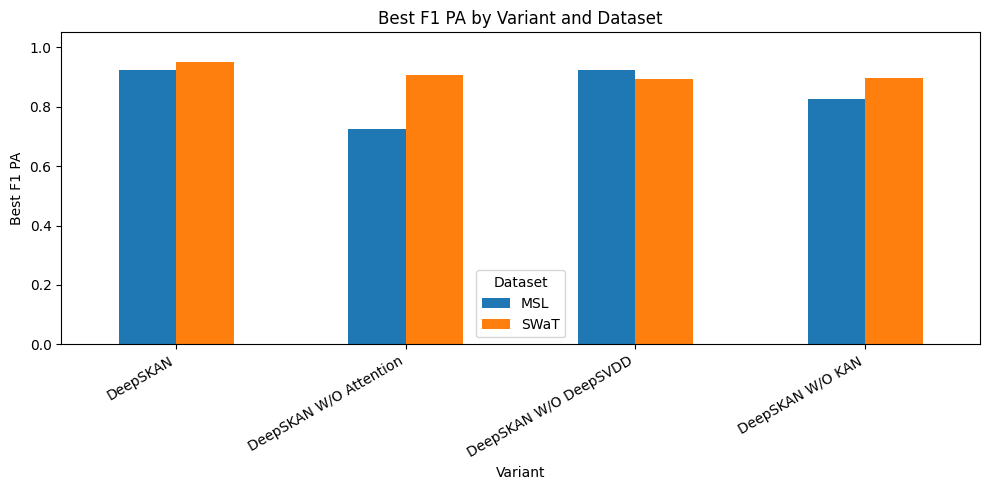

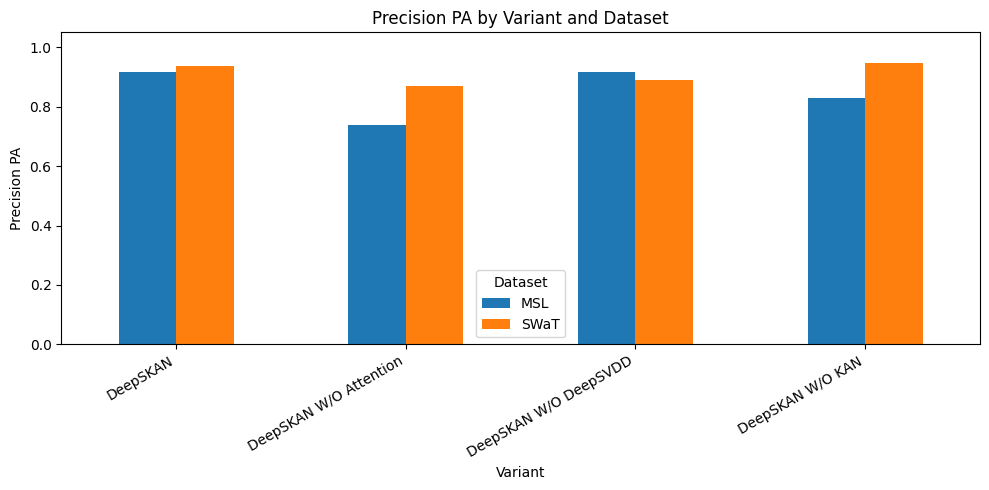

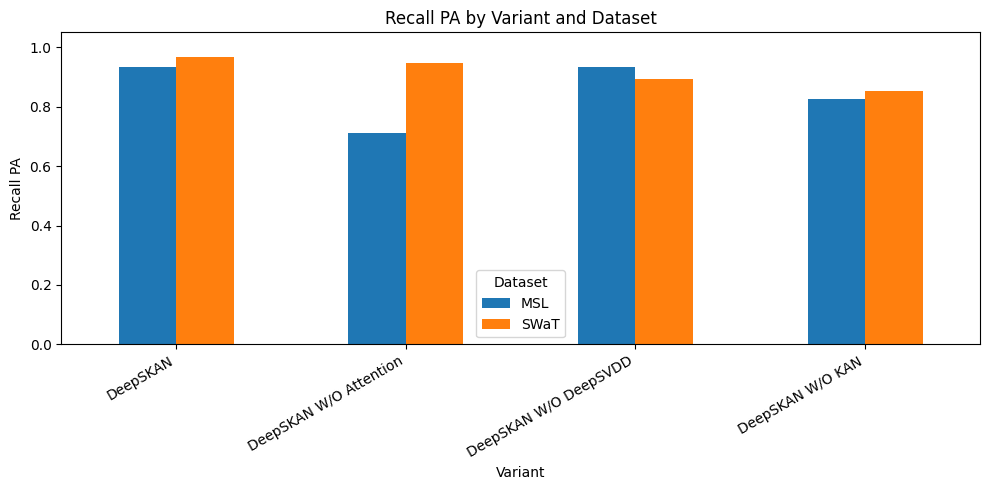

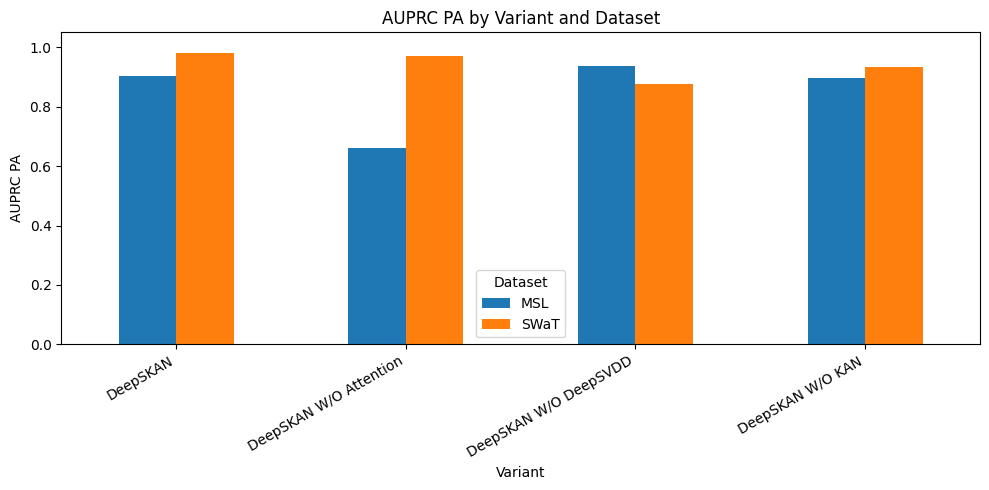

In [8]:
for metric in main_metrics:
    pivot_metric = df.pivot(index="Variant", columns="Dataset", values=metric)
    ax = pivot_metric.plot(kind="bar", figsize=(10, 5))
    plt.title(f"{metric} by Variant and Dataset")
    plt.ylabel(metric)
    plt.xlabel("Variant")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1.05)
    plt.legend(title="Dataset")
    plt.tight_layout()
    plt.show()

# Final interpretation

## Dataset-level conclusion

Using the four main metrics together:

- On **MSL**, the best variant is **DeepSKAN W/O DeepSVDD**.
- On **SWaT**, the best variant is **DeepSKAN**.

## Overall conclusion

Across both datasets, the best model is **DeepSKAN**, because it obtains the highest overall average score across the four main metrics.

This supports the usefulness of combining **Wavelet KAN**, **DeepSVDD**, and **Attention**, especially because the full model performs clearly best on SWaT and remains highly competitive on MSL.

## Component-level interpretation

- Removing **Attention** causes a large performance drop, especially on MSL. This suggests that attention is important for capturing relevant temporal or feature dependencies.
- Removing **KAN** also reduces the overall performance, especially compared with the full model on SWaT. This suggests that the Wavelet KAN component contributes useful nonlinear representation power.
- Removing **DeepSVDD** gives the best MSL result by a very small margin, but it performs much worse than the full model on SWaT. This suggests that DeepSVDD improves robustness and generalization, especially on SWaT.

Therefore, the full **DeepSKAN** model is the strongest overall architecture.